<p style="background-color:#005979;color:white;font-size:24px;text-align:center;border-radius:05px 05px;font-weight:bold;border:2px;padding: 10px;">Spaceship Titanic 🚀 CatBoost </p>

<center><img src= "https://new-science.ru/wp-content/uploads/2019/11/5623.jpg" style='width:800px;'></center><br>

The Spaceship Titanic was an interstellar passenger liner launched a month ago. With almost 13,000 passengers on board, the vessel set out on its maiden voyage transporting emigrants from our solar system to three newly habitable exoplanets orbiting nearby stars.

While rounding Alpha Centauri en route to its first destination—the torrid 55 Cancri E—the unwary Spaceship Titanic collided with a spacetime anomaly hidden within a dust cloud. Sadly, it met a similar fate as its namesake from 1000 years before. Though the ship stayed intact, almost half of the passengers were transported to an alternate dimension!

<p style="background-color:#005979;color:white;font-size:20px;text-align:center;border-radius:10px 10px;font-weight:bold;border:2px;padding: 10px">Importing</p>

In [1]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing

# Model
from catboost import CatBoostClassifier

In [2]:
df_train = pd.read_csv('../input/spaceship-titanic/train.csv')
df_test = pd.read_csv('../input/spaceship-titanic/test.csv')

df_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [3]:
r1,c1 = df_train.shape
print('The training data has {} rows and {} columns'.format(r1,c1))
r2,c2 = df_test.shape
print('The validation data has {} rows and {} columns'.format(r2,c2))

The training data has 8693 rows and 14 columns
The validation data has 4277 rows and 13 columns


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [5]:
df_train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [6]:
df_test.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,4186.000000,4195.000000,4171.000000,4179.000000,4176.000000,4197.000000
mean,28.658146,219.266269,439.484296,177.295525,303.052443,310.710031
std,14.179072,607.011289,1527.663045,560.821123,1117.186015,1246.994742
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,53.000000,78.000000,33.000000,50.000000,36.000000
max,79.000000,11567.000000,25273.000000,8292.000000,19844.000000,22272.000000


In [7]:
# To see the null vaues in all the columns

print('Missing values in train:')
print(df_train.isna().sum())
print('')
print('Missing values in test:')
print(df_test.isna().sum())

Missing values in train:
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

Missing values in test:
PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64


In [8]:
# df_train.set_index('PassengerId',inplace=True)
# df_test.set_index('PassengerId',inplace=True)

In [9]:
# df_train.head()

In [10]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [11]:
not_bool = {False:0, True:1}
df_train['Transported'] = df_train['Transported'].map(not_bool)
df_train['VIP'] = df_train['VIP'].map(not_bool)
df_train['CryoSleep'] = df_train['CryoSleep'].map(not_bool)

In [12]:
# object_cols = [col for col in df_train.columns
#                if df_train[col].dtype == 'object']
# num_cols = [col for col in df_train.columns
#             if df_train[col].dtype in ['float64', 'bool', 'int64']]

In [13]:
# object_cols, num_cols

In [14]:
# df_train[num_cols].head()

<p style="background-color:#005979;color:white;font-size:20px;text-align:center;border-radius:10px 10px;font-weight:bold;border:2px;padding: 10px">Visualization and replacement</p>


In [15]:
sns.color_palette("viridis")

[(0.275191, 0.194905, 0.496005),
 (0.212395, 0.359683, 0.55171),
 (0.153364, 0.497, 0.557724),
 (0.122312, 0.633153, 0.530398),
 (0.288921, 0.758394, 0.428426),
 (0.626579, 0.854645, 0.223353)]

<AxesSubplot:xlabel='HomePlanet', ylabel='count'>

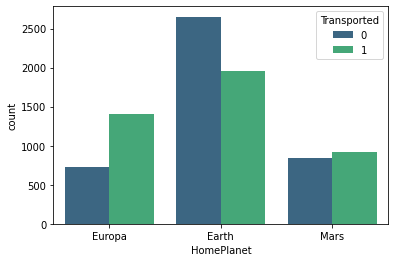

In [16]:
sns.countplot(x = 'HomePlanet', hue = 'Transported', data = df_train, palette = "viridis")

(array([0, 1, 2]),
 [Text(0, 0, 'TRAPPIST-1e'),
  Text(1, 0, 'PSO J318.5-22'),
  Text(2, 0, '55 Cancri e')])

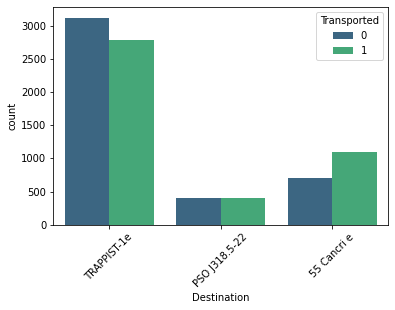

In [17]:
sns.countplot(x = 'Destination', hue = 'Transported', data = df_train, palette = "viridis")
plt.xticks(rotation = 45)

<AxesSubplot:xlabel='CryoSleep', ylabel='count'>

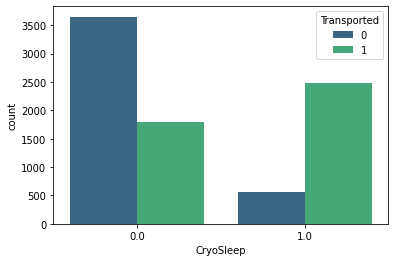

In [18]:
sns.countplot(x = 'CryoSleep', hue = 'Transported', data = df_train, palette = "viridis")

<AxesSubplot:xlabel='VIP', ylabel='count'>

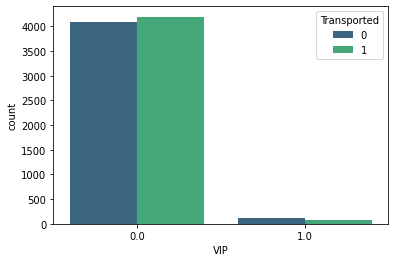

In [19]:
sns.countplot(x = 'VIP', hue = 'Transported', data = df_train, palette = "viridis")

In [20]:
n_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in n_cols:
    print(df_train[col].value_counts(ascending = False).index[0])
# print(df_train['RoomService'].value_counts(ascending = False).index[0])
# print(df_train['FoodCourt'].value_counts(ascending = False).index[0])
# print(df_train['ShoppingMall'].value_counts(ascending = False).index[0])
# print(df_train['Spa'].value_counts(ascending = False).index[0])
# print(df_train['VRDeck'].value_counts(ascending = False).index[0])

0.0
0.0
0.0
0.0
0.0


<p style="background-color:#005979;color:white;font-size:20px;text-align:center;border-radius:10px 10px;font-weight:bold;border:2px;padding: 10px">Replacing null values</p>

In [21]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   float64
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   float64
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   int64  
dtypes: float64(8), int64(1), object(5)
memory usage: 950.9+ KB


In [22]:
df_train[n_cols] = df_train[n_cols].fillna(0)
df_test[n_cols] = df_test[n_cols].fillna(0)

df_train[['VIP', 'CryoSleep']] = df_train[['VIP', 'CryoSleep']].fillna(0)
df_test[['VIP', 'CryoSleep']] = df_test[['VIP', 'CryoSleep']].fillna(0)

df_train['Age'] = df_train['Age'].fillna(df_train['Age'].median())
df_test['Age'] = df_test['Age'].fillna(df_test['Age'].median())

df_train['Destination'] = df_train['Destination'].fillna('TRAPPIST-1e')
df_test['Destination'] = df_test['Destination'].fillna('TRAPPIST-1e')

df_train['HomePlanet'] = df_train['HomePlanet'].fillna('Earth')
df_test['HomePlanet'] = df_test['HomePlanet'].fillna('Earth')

In [23]:
df_train['Age'].median(), df_test['Age'].median()

(27.0, 26.0)

In [24]:
df_train[['Deck', 'Num', 'Side']] = df_train['Cabin'].str.split('/', expand=True)   
df_test[['Deck', 'Num', 'Side']] = df_test['Cabin'].str.split('/', expand=True)

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='Deck', ylabel='count'>

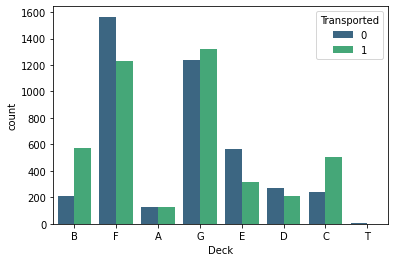

In [25]:
sns.countplot(df_train.Deck, hue = df_train.Transported, palette = "viridis")

In [26]:
df_train['Deck'].value_counts(), df_train['Num'].value_counts(), df_train['Side'].value_counts()

(F    2794
 G    2559
 E     876
 B     779
 C     747
 D     478
 A     256
 T       5
 Name: Deck, dtype: int64,
 82      28
 86      22
 19      22
 56      21
 176     21
         ..
 1644     1
 1515     1
 1639     1
 1277     1
 1894     1
 Name: Num, Length: 1817, dtype: int64,
 S    4288
 P    4206
 Name: Side, dtype: int64)

In [27]:
df_test['Deck'].value_counts(), df_test['Num'].value_counts(), df_test['Side'].value_counts()

(F    1445
 G    1222
 E     447
 B     362
 C     355
 D     242
 A      98
 T       6
 Name: Deck, dtype: int64,
 4       21
 31      18
 197     16
 294     16
 228     14
         ..
 1170     1
 904      1
 1174     1
 356      1
 1503     1
 Name: Num, Length: 1505, dtype: int64,
 S    2093
 P    2084
 Name: Side, dtype: int64)

In [28]:
df_train['Num'] = df_train['Num'].fillna(82).astype(float)
df_train['Deck'] = df_train['Deck'].fillna('F')
df_train['Side'] = df_train['Side'].fillna('S')

df_test['Num'] = df_test['Num'].fillna(4).astype(float)
df_test['Deck'] = df_test['Deck'].fillna('F')
df_test['Side'] = df_test['Side'].fillna('S')

In [29]:
df_train.isna().sum()

PassengerId       0
HomePlanet        0
CryoSleep         0
Cabin           199
Destination       0
Age               0
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Name            200
Transported       0
Deck              0
Num               0
Side              0
dtype: int64

In [30]:
ohe_col = ['HomePlanet', 'Destination', 'Deck', 'Side']
for col in ohe_col:
    df_train[pd.get_dummies(df_train[col]).columns] = pd.get_dummies(df_train[col])
    df_test[pd.get_dummies(df_test[col]).columns] = pd.get_dummies(df_test[col])

In [31]:
PassengerId = df_test.PassengerId
df_train = df_train.drop(['Destination', 'HomePlanet', 'Cabin', 'PassengerId', 'Name', 'Deck', 'Side'], axis = 1)
df_test = df_test.drop(['Destination', 'HomePlanet', 'Cabin', 'PassengerId', 'Name', 'Deck', 'Side'], axis = 1)

<p style="background-color:#005979;color:white;font-size:20px;text-align:center;border-radius:10px 10px;font-weight:bold;border:2px;padding: 10px">Feature Engineering</p>

In [32]:
df_train['total_spent'] = df_train['Spa'] + df_train['VRDeck'] + df_train['ShoppingMall'] + df_train['FoodCourt'] + df_train['RoomService']
df_test['total_spent'] = df_test['Spa'] + df_test['VRDeck'] + df_test['ShoppingMall'] + df_test['FoodCourt'] + df_test['RoomService']

In [33]:
df_train['AgeGroup'] = 0
for i in range(8):
    df_train.loc[(df_train.Age >= 10*i) & (df_train.Age < 10*(i + 1)), 'AgeGroup'] = i
    
# Same for test data

df_test['AgeGroup'] = 0
for i in range(8):
    df_test.loc[(df_test.Age >= 10*i) & (df_test.Age < 10*(i + 1)), 'AgeGroup'] = i

<AxesSubplot:xlabel='count', ylabel='AgeGroup'>

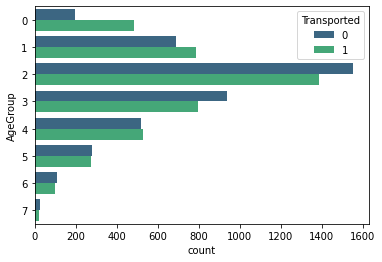

In [34]:
sns.countplot(y = df_train['AgeGroup'], hue = df_train.Transported, palette = "viridis")

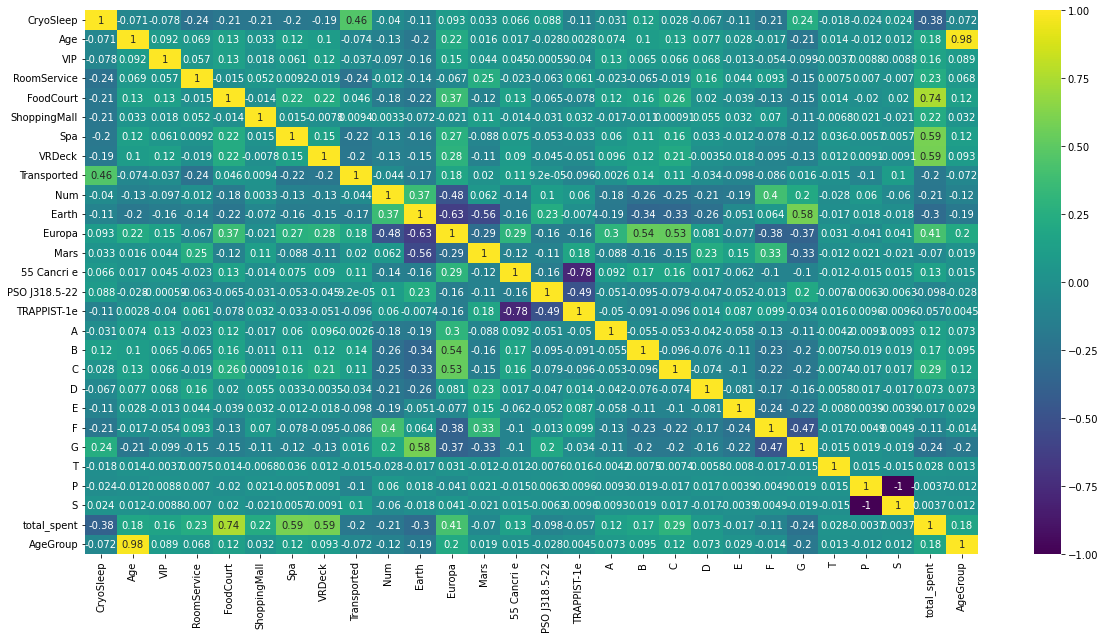

In [35]:
plt.figure(figsize=(20,10))
sns.heatmap(df_train.corr(), annot=True, cmap = "viridis");

In [36]:
y = df_train.Transported
df_train = df_train.drop(['Transported', 'Age'], axis = 1)
df_test = df_test.drop(['Age', ], axis = 1)

<p style="background-color:#005979;color:white;font-size:20px;text-align:center;border-radius:10px 10px;font-weight:bold;border:2px;padding: 10px">MinMaxScaler</p>

In [37]:
min_max_Scalar = preprocessing.MinMaxScaler()

In [38]:
df_train.shape, df_test.shape

((8693, 26), (4277, 26))

In [39]:
col = df_train.columns
df_train = pd.DataFrame(min_max_Scalar.fit_transform(df_train), columns=col)
df_test = pd.DataFrame(min_max_Scalar.transform(df_test), columns=col)

In [40]:
# Splitting Columns

X_train, X_val, y_train, y_val = train_test_split(df_train, y, test_size=0.3, random_state=0)

<p style="background-color:#005979;color:white;font-size:20px;text-align:center;border-radius:10px 10px;font-weight:bold;border:2px;padding: 10px">СatBoost</p>

In [41]:
model = CatBoostClassifier(iterations = 5000,
                           #max_depth = 6,
                         #eval_metric='Accuracy',
                        verbose=0)

In [42]:
%%time
model.fit(X_train, y_train)

CPU times: user 59.2 s, sys: 12.8 s, total: 1min 11s
Wall time: 23 s


In [43]:
pred_y = model.predict(X_val)

pred = model.predict(X_train)
    
print(accuracy_score(y_train.values, pred))
print(accuracy_score(y_val.values, pred_y))

0.8836483155299918
0.8136503067484663


In [44]:
0.8797041906327033
0.8132668711656442

0.8746096959737059
0.8151840490797546

0.8151840490797546

In [45]:
y_pred = model.predict(df_test)

<p style="background-color:#005979;color:white;font-size:20px;text-align:center;border-radius:10px 10px;font-weight:bold;border:2px;padding: 10px">Submission</p>

In [46]:
submission = pd.DataFrame({'Transported':y_pred.astype(bool)},index = PassengerId)

submission.head()

,Transported
PassengerId,
0013_01,True
0018_01,False
0019_01,True
0021_01,True
0023_01,False


In [47]:
submission.to_csv('submission_cat_8')